## Setup

**Test date: 1.5.2026**

**CPU**: AMD Ryzen 9 7950X 16-Core Processor

**RAM**: 128GB DDR5 G-Skill Trident Z5

**GPU**: NVIDIA RTX 4090

Running on **Ollama v0.21.0** and **Open WebUI v0.9.2** as the interface.

**Devstral** was tasked with generating a **couch** using the **SPOMSO** package. The model was provided with the [spomso_sdf_guide](./guides/spomso_sdf_guide.md) file and the following prompt:

*Read through the attached .md file. It contains a guide how to use the Python package SPOMSO. I want you to design a couch using this Python package. As the output I want some code that I would run and it would output the point cloud of the object and some figures. Make sure that the resulting plots show true proportions of the object. Everything else I leave up to you. Good luck and if you have any questions feel free to ask.*

## Response:

I'll design a simple couch using SPOMSO based on the information provided in the guide. Here's a Python script that creates a basic couch shape, generates a point cloud for its surface, and produces cross-section plots:

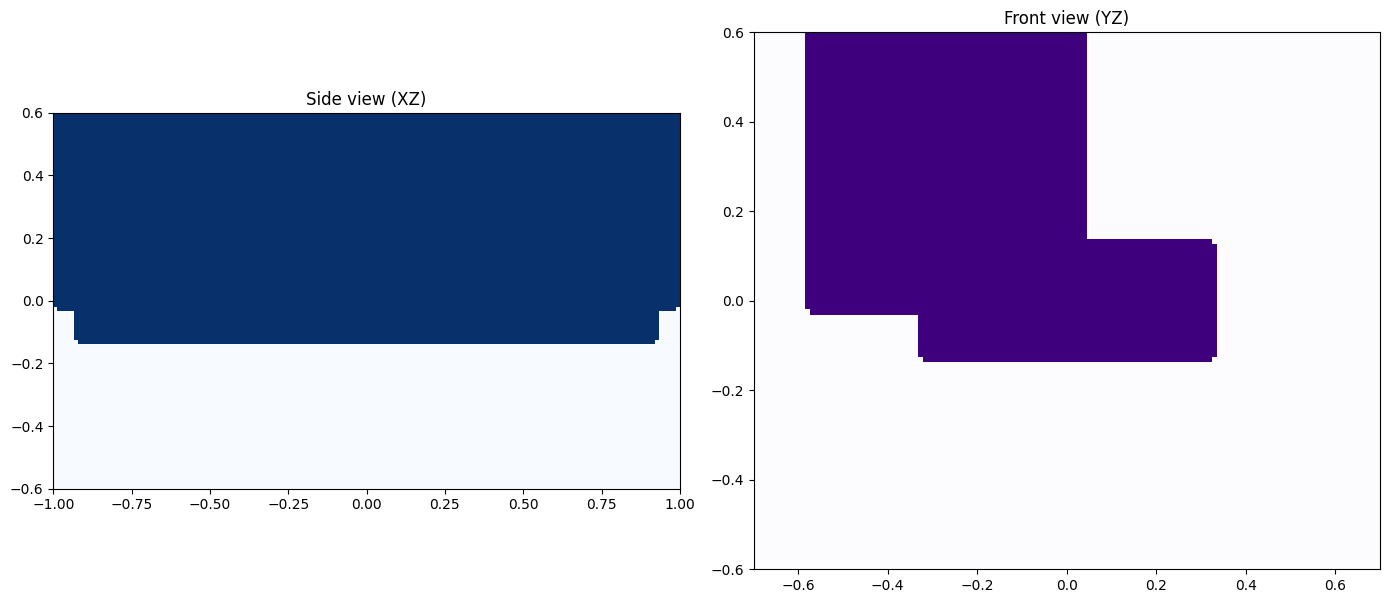

Point cloud saved: 103,747 points


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spomso.cores.helper_functions import generate_grid, smarter_reshape
from spomso.cores.post_processing import hard_binarization
from spomso.cores.geom_3d import Box, Cylinder
from spomso.cores.combine import CombineGeometry

# Grid setup
CO_SIZE = (2.0, 1.4, 1.2)  # Larger width for couch shape
CO_RESOLUTION = (150, 110, 90)
coor, co_res_new = generate_grid(CO_SIZE, CO_RESOLUTION)

# Couch seat base
seat_base = Box(1.8, 0.6, 0.2)
seat_base.rounding(0.04)  # Round the edges for comfort

# Couch backrest
backrest = Box(1.7, 0.55, 0.7)
backrest.rounding(0.04)
backrest.move((0.0, -0.275, 0.35))  # Position the backrest above the seat

# Couch armrests (left and right)
arm_left = Box(0.15, 0.6, 0.8)
arm_right = Box(0.15, 0.6, 0.8)
arm_left.rounding(0.03)
arm_right.rounding(0.03)
arm_left.move((-0.9, -0.275, 0.4))
arm_right.move((0.9, -0.275, 0.4))

# Couch legs (4 legs)
leg_positions = [
    (-0.8, 0.3, -0.1),   # Front left
    (0.8, 0.3, -0.1),    # Front right
    (-0.8, -0.57, -0.1), # Back left
    (0.8, -0.57, -0.1)   # Back right
]
legs = []
for pos in leg_positions:
    leg = Cylinder(0.06, 0.2)
    leg.rounding(0.02)
    leg.move(pos)
    legs.append(leg)

# Combine all parts to create the couch
couch = CombineGeometry("UNION").combine(
    seat_base, backrest, arm_left, arm_right, *legs
)

sdf = couch.create(coor)

# Binary field and cross-sections
binary_3d = smarter_reshape(hard_binarization(sdf, 0), CO_RESOLUTION)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(binary_3d[:, CO_RESOLUTION[1]//2, :].T,
              cmap="Blues", origin="lower",
              extent=(-CO_SIZE[0]/2, CO_SIZE[0]/2, -CO_SIZE[2]/2, CO_SIZE[2]/2))
axes[0].set_title("Side view (XZ)")

axes[1].imshow(binary_3d[CO_RESOLUTION[0]//2, :, :].T,
              cmap="Purples", origin="lower",
              extent=(-CO_SIZE[1]/2, CO_SIZE[1]/2, -CO_SIZE[2]/2, CO_SIZE[2]/2))
axes[1].set_title("Front view (YZ)")
plt.tight_layout()
plt.show()

# Surface point cloud
dx = CO_SIZE[0] / CO_RESOLUTION[0]
surface_pts = coor[:, np.abs(sdf) < dx * 1.5].T
np.save("couch_surface.npy", surface_pts)
print(f"Point cloud saved: {surface_pts.shape[0]:,} points")

This script creates a simple couch with a seat, backrest, armrests, and legs. It then generates cross-sectional views of the couch and saves the point cloud representation of its surface.

Key design decisions:
1. The overall dimensions of the couch are approximately 2 meters wide, 1.4 meters deep, and 0.7 meters high at the highest point.
2. I used basic geometric primitives (boxes for seat/backrest/armrests and cylinders for legs).
3. I added some rounding to edges for a more comfortable look.
4. The grid resolution is set relatively high to capture fine details while keeping computational demands reasonable.

To run this script, make sure you have the SPOMSO library installed as described in the guide, along with required dependencies like `numpy`, `matplotlib`, etc. The output will include two cross-sectional views of the couch (side and front) and a saved point cloud file named "couch_surface.npy".

**End response**

**Approximate time:** 23s

## Validation

The entire **object** can be visualized with the code below:

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=go.Volume(
    x=coor[0],
    y=coor[1],
    z=coor[2],
    value=hard_binarization(sdf, 0),
    isomin=0.9,
    isomax=1,
    opacity=1,
    surface_count=2,
))
fig.show()